# Grammar Scoring Engine for Spoken English

**Task.** Given a 45–60 s recording of someone speaking English, predict a continuous grammar score from 0 to 5 (MOS Likert scale, rubric below).
**Data.** 769 labelled training clips, 216 test clips (16 kHz mono `.wav`). **Metric.** RMSE (leaderboard), Pearson r reported alongside.

| Score | Rubric (abridged) |
|---|---|
| 1 | struggles with sentence structure; limited control of simple structures |
| 2 | limited understanding of structure; consistent basic mistakes; incomplete sentences |
| 3 | decent grasp of structure but errors in grammar or syntax |
| 4 | strong grasp; occasional minor errors that do not cause misunderstanding |
| 5 | high accuracy and control of complex grammar; self-corrects |

## Report summary

**Approach.** Two complementary views of every clip are combined:

* *How it sounds* — speech encoders (WavLM) capture fluency, hesitation and pronunciation, which correlate strongly with grammatical control.
* *What was said* — the clip is transcribed with Whisper and a DeBERTa-v3 language model is fine-tuned to score the transcript directly.

Each base model produces **out-of-fold (OOF)** predictions; a small non-negative linear **stack** combines four of them, with **separate weights for short (~45 s) and long (~60 s) clips**.

**Three findings drove the design** (each is demonstrated below):

1. **37 training clips labelled 0 are white noise**, not speech — trivially detectable, and absent from the test set. They are removed from training and handled by a rule.
2. **The test set is mostly short clips** (69 % are ~45 s vs 24 % of training). Audio models degrade badly on short clips while text models do not, so the stack learns per-length weights and model selection uses a *test-mix* RMSE (69 % short / 31 % long).
3. **Fewer stack inputs generalise better.** Repeated nested CV chose 4 base models out of 18 candidates.

**Results.** Cross-validated RMSE 0.45 (r 0.90) on speech clips; public leaderboard RMSE **0.3351**. Training-set RMSE is reported in Section 8.

## Pipeline architecture

```
 .wav (16 kHz mono)
   │
   ├── noise check: zero-crossing rate > 0.4 ───────────────────────► score 0 (rule)
   │
   ├── Whisper large-v3-turbo ─► transcript ─┬─ DeBERTa-v3-large  (fine-tuned, 5-fold × 2 seeds) ─┐
   │                                          └─ DeBERTa-v3-base   (fine-tuned, 5-fold × 3 seeds) ─┤
   │                                                                                                ├─► length-aware
   ├── WavLM-base+   (fine-tuned end-to-end, 5-fold; 15 s crops, layer-weighted mean pooling) ──────┤    non-negative
   │                                                                                                │    linear stack
   └── WavLM-large   (frozen; mean of layers 20–21) ─► SVR (5-fold × 3 seeds) ──────────────────────┘    (short / long)
                                                                                                          │
                                                                                                          ▼
                                                                                                 score, clipped to [1, 5]
```

Heavy GPU steps live in scripts (`src/`, `kaggle/`) and cache their outputs in `features/`; this notebook loads those caches, reruns all classical modelling, stacking and evaluation, and writes `submission.csv`.

| Step | Script | Hardware |
|---|---|---|
| Whisper transcripts | `src/transcribe.py` | local GPU |
| prosody stats + WavLM-base embeddings | `src/audio_feats.py` | local GPU |
| WavLM-large / Whisper-encoder embeddings | `src/ssl_feats.py`, `src/whisper_feats.py` | local GPU |
| transcript stats, GPT-2 likelihood, sentence / LLM embeddings | `src/text_feats.py`, `src/llm_feats.py` | local GPU |
| DeBERTa-v3-base fine-tune | `src/finetune_text.py` | local GPU |
| DeBERTa-v3-large, WavLM fine-tunes | `kaggle/*.py` | Kaggle T4 |

In [1]:
# Setup: all modelling code lives in src/; this notebook orchestrates and explains it.
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore")
sys.path.insert(0, "src")
import train                                   # base-model CV, stacking helpers
from common import FEAT, DATA, load_meta

# Chart style: one blue for single series, blue/orange for two groups; muted grid and text.
BLUE, ORANGE, AQUA, INK, MUTED = "#2a78d6", "#eb6834", "#1baf7a", "#0b0b0b", "#52514e"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": MUTED, "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
                     "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.8, "axes.axisbelow": True,
                     "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold", "legend.frameon": False})

## 1. Data overview

train clips 769, test clips 216
label mean 3.31, std 1.24


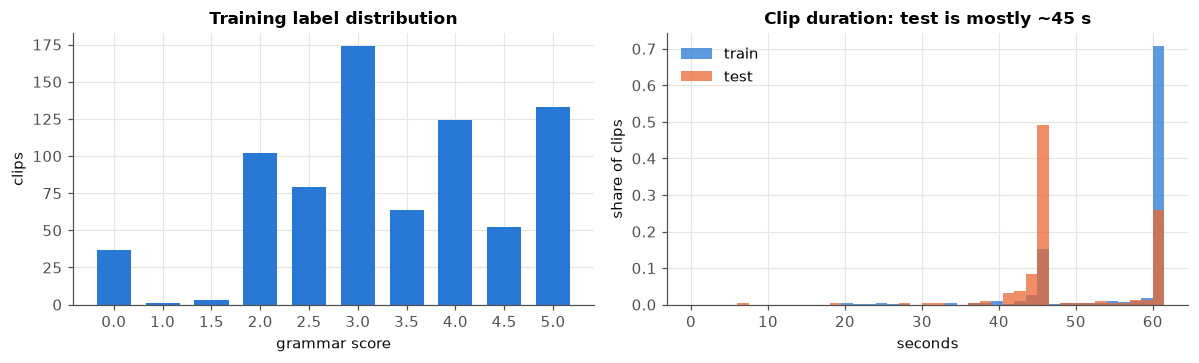

share of ~45 s clips: train 24%, test 69%


In [2]:
meta = load_meta()                                         # train rows then test rows; key = split/filename
pros = pd.read_csv(FEAT / "prosody.csv")                   # per-clip audio statistics (src/audio_feats.py)
assert (pros.key == meta.key).all()
meta["dur"] = pros.dur.values
tr = meta[meta.split == "train"]
print(f"train clips {len(tr)}, test clips {(meta.split == 'test').sum()}")
print(f"label mean {tr.label.mean():.2f}, std {tr.label.std():.2f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
counts = tr.label.value_counts().sort_index()
ax[0].bar(counts.index.astype(str), counts.values, color=BLUE, width=0.7)
ax[0].set(title="Training label distribution", xlabel="grammar score", ylabel="clips")
bins = np.arange(0, 63, 1.5)
for split, col in [("train", BLUE), ("test", ORANGE)]:
    d = meta[meta.split == split].dur
    ax[1].hist(d, bins=bins, color=col, alpha=0.75, weights=np.ones(len(d)) / len(d), label=split)
ax[1].set(title="Clip duration: test is mostly ~45 s", xlabel="seconds", ylabel="share of clips")
ax[1].legend()
plt.tight_layout(); plt.show()

short = (meta.dur < 50).values
print(f"share of ~45 s clips: train {short[meta.split == 'train'].mean():.0%}, test {short[meta.split == 'test'].mean():.0%}")

Labels are on a half-point grid and skewed towards 3–5. The score 0 is **not part of the rubric**, yet 37 clips carry it — investigated next.
The duration plot shows a **train/test shift**: most test clips are ~45 s recordings, most training clips ~60 s. Listening to transcripts shows both lengths are cut mid-sentence, i.e. the same kind of answer truncated at a different time limit.

## 2. Preprocessing

**Audio.** All files are already 16 kHz mono; they are loaded with `librosa` (resampling would happen there if needed) and amplitude-normalised per clip before the speech encoders.

**Noise clips.** The 37 label-0 clips have nearly constant energy and a very high zero-crossing rate — the signature of white noise rather than speech.

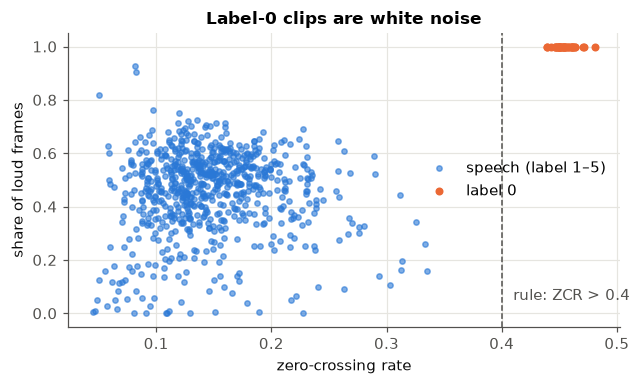

rule flags 37 train clips (all label 0: True), 0 test clips
max ZCR of real speech 0.335 vs min ZCR of noise 0.439


In [3]:
is_zero = (tr.label == 0).values
p_tr = pros[pros.split == "train"]
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.scatter(p_tr.zcr[~is_zero], p_tr.voiced_ratio[~is_zero], s=12, color=BLUE, alpha=0.6, label="speech (label 1–5)")
ax.scatter(p_tr.zcr[is_zero], p_tr.voiced_ratio[is_zero], s=18, color=ORANGE, label="label 0")
ax.axvline(0.4, color=MUTED, ls="--", lw=1); ax.text(0.41, 0.05, "rule: ZCR > 0.4", color=MUTED)
ax.set(title="Label-0 clips are white noise", xlabel="zero-crossing rate", ylabel="share of loud frames")
ax.legend(loc="center right"); plt.tight_layout(); plt.show()

noise = (pros.zcr > 0.4).values
print(f"rule flags {noise[meta.split == 'train'].sum()} train clips (all label 0: {(tr.label[noise[meta.split == 'train']] == 0).all()}), "
      f"{noise[meta.split == 'test'].sum()} test clips")
print(f"max ZCR of real speech {p_tr.zcr[~is_zero].max():.3f} vs min ZCR of noise {p_tr.zcr[is_zero].min():.3f}")

The rule separates the groups with a wide margin and finds **no noise in the test set**, so every model below is trained on the 732 speech clips only (keeping the noise clips would let them dominate RMSE and inflate Pearson without helping on test).

**Transcription.** Whisper large-v3-turbo (fp16, 30 s chunks, greedy decoding, English) produces one transcript per clip (`src/transcribe.py`). Whisper tends to keep learners' grammatical errors (e.g. *"having a more more greenery trees"* survives), which is what the text models need.

**Feature extraction** (cached; rerun with the scripts listed above):

* **WavLM-large, frozen** — hidden states mean-pooled over time; a per-layer CV sweep picked layers 20–21.
* **Fine-tuned WavLM-base+** — the whole encoder is trained to regress the score on random 15 s crops; a learned softmax mixes all 13 layers, then mean pooling and a linear head. Test-time score = mean over consecutive 15 s windows.
* **Fine-tuned DeBERTa-v3** — transcript → regression head, MSE on standardised targets, 6 (base) / 5 (large) epochs, cosine schedule.

## 3. Base models — cross-validation

Every base model is evaluated with **5-fold CV stratified on the label, repeated over 3 seeds**; the out-of-fold predictions become the inputs of the stack. Errors are reported on all speech clips, on short and long clips separately, and as a **test-mix RMSE** that re-weights short/long to the test proportions (69 % / 31 %).

In [4]:
meta_b, blocks, noise, short_all = train.load()
trn = (meta_b.split == "train").values & ~noise           # speech training clips
tst = (meta_b.split == "test").values
y = meta_b.label[trn].values
short, short_te = short_all[trn], short_all[tst]

def rmse(p, m=None):
    m = np.ones(len(y), bool) if m is None else m
    return np.sqrt(np.mean((p[m] - y[m]) ** 2))

def row(name, p):
    return dict(model=name, rmse=rmse(p), pearson=pearsonr(p, y)[0], short=rmse(p, short), long=rmse(p, ~short),
                test_mix=np.sqrt(.69 * rmse(p, short) ** 2 + .31 * rmse(p, ~short) ** 2))

oofs, tes = {}, {}
for name, (b, est) in train.models().items():            # classical models on cached embeddings
    if b in blocks:
        oofs[name], tes[name] = train.cv(blocks[b][trn], y, blocks[b][tst], est)
for f in sorted(FEAT.glob("ft_*_oof.npy")):              # fine-tuned transformers (OOF made by their own 5-fold runs)
    name = f.stem[3:-4]
    oofs[name], tes[name] = np.load(f), np.load(str(f).replace("_oof", "_test"))

table = pd.DataFrame([row(n, p) for n, p in oofs.items()]).sort_values("test_mix").set_index("model")
table.round(3)

,rmse,pearson,short,long,test_mix
model,,,,,
deberta-v3-large,0.565,0.835,0.534,0.575,0.547
deberta-v3-base,0.579,0.825,0.542,0.590,0.558
whisper_ridge,0.554,0.838,0.597,0.539,0.580
qwen_ridge,0.602,0.805,0.569,0.612,0.583
wavlm_large_ridge,0.550,0.840,0.605,0.532,0.583
whisper_svr,0.551,0.842,0.606,0.533,0.585
wavlm_large_svr,0.537,0.852,0.623,0.506,0.589
qwen_svr,0.598,0.811,0.586,0.602,0.591
t45_wavlm_svr,0.546,0.846,0.625,0.518,0.594


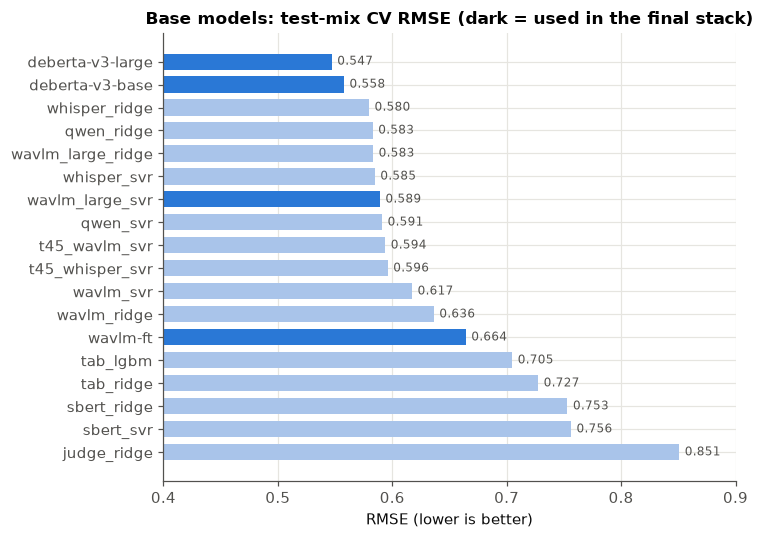

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
t = table.sort_values("test_mix", ascending=False)
colors = [BLUE if n in train.STACK else "#a9c4ea" for n in t.index]
ax.barh(t.index, t.test_mix, color=colors, height=0.7)
for i, v in enumerate(t.test_mix):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", color=MUTED, fontsize=8)
ax.set(title="Base models: test-mix CV RMSE (dark = used in the final stack)", xlabel="RMSE (lower is better)", xlim=(0.4, 0.9))
plt.tight_layout(); plt.show()

**Reading the table.** Hand-crafted features (prosody, transcript statistics, GPT-2 likelihood) and generic sentence embeddings are clearly weaker than the large pretrained encoders. Among those, the **best audio and the best text models are close overall but behave very differently by clip length:**

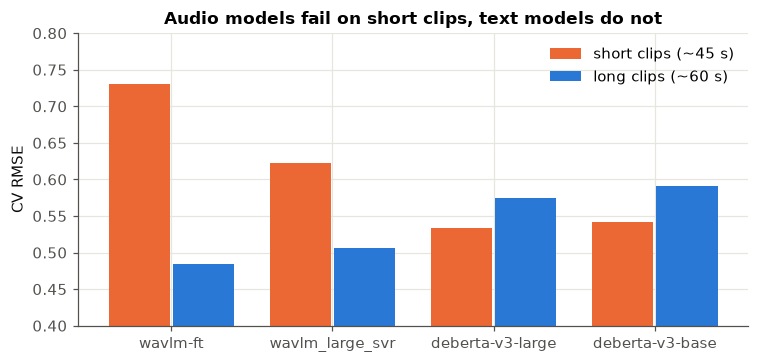

,short,long
model,,
wavlm-ft,0.731,0.484
wavlm_large_svr,0.623,0.506
deberta-v3-large,0.534,0.575
deberta-v3-base,0.542,0.590


In [6]:
core = train.STACK
x = np.arange(len(core))
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.bar(x - 0.2, table.loc[core, "short"], 0.38, color=ORANGE, label="short clips (~45 s)")
ax.bar(x + 0.2, table.loc[core, "long"], 0.38, color=BLUE, label="long clips (~60 s)")
ax.set_xticks(x, core); ax.set(title="Audio models fail on short clips, text models do not", ylabel="CV RMSE", ylim=(0.4, 0.8))
ax.legend(); plt.tight_layout(); plt.show()
table.loc[core, ["short", "long"]].round(3)

The fine-tuned WavLM is the best model of all on long clips (0.48) and the worst on short ones (0.73), while DeBERTa is better on short clips. A single set of stack weights would be tuned for the long clips that dominate training — the opposite of the test set. Hence the **length-aware stack**.

A tested alternative, re-embedding long training clips truncated to their first 45 s (`src/trunc_feats.py`) to mimic test conditions, did **not** improve short-clip error (0.623 → 0.625), indicating short clips are intrinsically harder (their labels also vary less: std 0.89 vs 1.03) rather than merely shorter.

## 4. Stacking

For each length group the stack solves a **non-negative least-squares** problem on the OOF predictions with a free intercept:

$$\hat y = b + \sum_k w_k\,\hat y_k,\qquad w_k \ge 0.$$

Non-negativity keeps the blend interpretable and stable on few samples; the free intercept with weights summing slightly above 1 lets the stack *stretch* predictions, countering the regression-to-the-mean of every base model. Stack quality is measured with **nested CV** (weights fitted on 4/5 of the OOF rows, scored on the held-out 1/5), repeated over 5 seeds.

In [7]:
def nested_test_mix(cols, seeds=range(5)):
    O, res = np.column_stack([oofs[c] for c in cols]), []
    for s in seeds:
        out = np.zeros(len(y))
        for a, b in StratifiedKFold(5, shuffle=True, random_state=s).split(O, (y * 2).astype(int)):
            _, out[b], _ = train.stack_by_length(O[a], y[a], short[a], O[b], short[b])
        out = np.clip(out, 1, 5)
        res.append(np.sqrt(.69 * rmse(out, short) ** 2 + .31 * rmse(out, ~short) ** 2))
    return np.mean(res), np.std(res)

candidates = {"all base models": list(oofs), "top-6": train.STACK + ["whisper_svr", "qwen_ridge"], "core-4 (final)": train.STACK}
sel = pd.DataFrame({k: nested_test_mix(v) for k, v in candidates.items()}, index=["test-mix RMSE", "± over seeds"]).T
sel.insert(0, "inputs", [len(v) for v in candidates.values()])
sel.round(4)

,inputs,test-mix RMSE,± over seeds
all base models,18,0.4860,0.0023
top-6,6,0.4777,0.0035
core-4 (final),4,0.4769,0.0028


With 18 inputs the short-clip weights (fitted on only ~180 clips) overfit; four inputs — two audio, two text — generalise best. This choice was confirmed on the leaderboard (0.3401 → 0.3351).

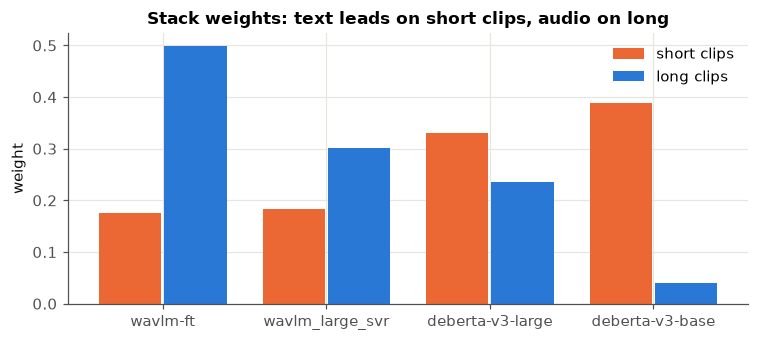

,short clips,long clips
wavlm-ft,0.176,0.499
wavlm_large_svr,0.183,0.301
deberta-v3-large,0.330,0.235
deberta-v3-base,0.389,0.039
intercept,-0.405,-0.273


In [8]:
O = np.column_stack([oofs[c] for c in train.STACK]); T = np.column_stack([tes[c] for c in train.STACK])
oof_in, pred, ws = train.stack_by_length(O, y, short, T, short_te)

w = pd.DataFrame({("short clips" if g else "long clips"): list(v[:-2]) + [v[-2] - v[-1]] for g, v in ws.items()},
                 index=train.STACK + ["intercept"])
fig, ax = plt.subplots(figsize=(7, 3.2))
x = np.arange(len(train.STACK))
ax.bar(x - 0.2, w.loc[train.STACK, "short clips"], 0.38, color=ORANGE, label="short clips")
ax.bar(x + 0.2, w.loc[train.STACK, "long clips"], 0.38, color=BLUE, label="long clips")
ax.set_xticks(x, train.STACK); ax.set(title="Stack weights: text leads on short clips, audio on long", ylabel="weight")
ax.legend(); plt.tight_layout(); plt.show()
w.round(3)

## 5. Evaluation on the training data

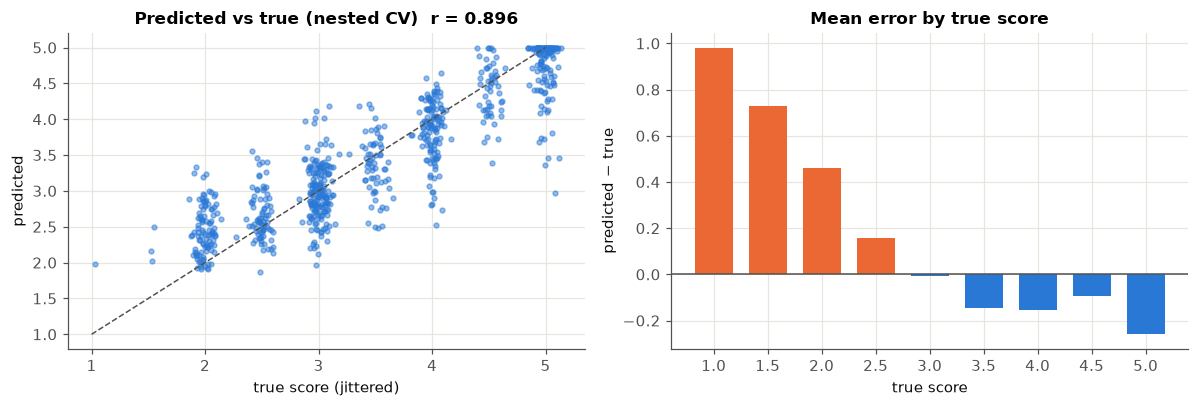

label,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0
n,1.000,3.000,102.000,79.000,174.000,64.000,124.000,52.000,133.000
mean error,0.982,0.729,0.461,0.157,-0.005,-0.144,-0.153,-0.094,-0.259
RMSE,0.982,0.754,0.572,0.379,0.393,0.436,0.440,0.386,0.474


In [9]:
# Honest estimate: nested-CV stack predictions for every speech clip.
nested = np.zeros(len(y))
for a, b in StratifiedKFold(5, shuffle=True, random_state=99).split(O, (y * 2).astype(int)):
    _, nested[b], _ = train.stack_by_length(O[a], y[a], short[a], O[b], short[b])
nested = np.clip(nested, 1, 5)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
jit = np.random.default_rng(0).normal(0, 0.06, len(y))
ax[0].scatter(y + jit, nested, s=10, alpha=0.5, color=BLUE)
ax[0].plot([1, 5], [1, 5], color=MUTED, ls="--", lw=1)
ax[0].set(title=f"Predicted vs true (nested CV)  r = {pearsonr(nested, y)[0]:.3f}", xlabel="true score (jittered)", ylabel="predicted")
err = pd.DataFrame({"label": y, "err": nested - y}).groupby("label").err
ax[1].bar(err.mean().index.astype(str), err.mean().values, color=[ORANGE if v > 0 else BLUE for v in err.mean().values], width=0.7)
ax[1].axhline(0, color=MUTED, lw=1)
ax[1].set(title="Mean error by true score", xlabel="true score", ylabel="predicted − true")
plt.tight_layout(); plt.show()
pd.DataFrame({"n": err.size(), "mean error": err.mean(), "RMSE": err.apply(lambda e: np.sqrt(np.mean(e ** 2)))}).round(3).T

Remaining errors are mostly **shrinkage at the extremes**: rare low scores (1–2) are over-predicted and 5s slightly under-predicted. Mid-range scores are predicted within ~0.4.

## 6. Training-set RMSE (required)

Reported on **all 769 training clips** (the 37 noise clips are scored 0 by the rule):

* **Cross-validated training RMSE** — every prediction comes from models that did not see that clip; this is the honest generalisation estimate.
* **In-sample training RMSE** — stack weights fitted on all training clips and applied back to them (base-model inputs are still out-of-fold, since the fine-tuned transformers are only ever trained within folds).

In [10]:
lab_all = meta_b.label[meta_b.split == "train"].values
noise_tr = noise[meta_b.split == "train"]

def full(pred_speech):                       # put speech predictions back alongside the rule-scored noise clips
    p = np.zeros(len(lab_all)); p[~noise_tr] = pred_speech; return p

res = {"cross-validated (nested)": full(nested), "in-sample stack": full(np.clip(oof_in, 1, 5))}
summary = pd.DataFrame({k: {"RMSE (all 769)": np.sqrt(np.mean((p - lab_all) ** 2)),
                            "Pearson (all 769)": pearsonr(p, lab_all)[0],
                            "RMSE (732 speech)": np.sqrt(np.mean((p[~noise_tr] - lab_all[~noise_tr]) ** 2)),
                            "Pearson (732 speech)": pearsonr(p[~noise_tr], lab_all[~noise_tr])[0]} for k, p in res.items()}).T
summary.round(4)

,RMSE (all 769),Pearson (all 769),RMSE (732 speech),Pearson (732 speech)
cross-validated (nested),0.4389,0.9351,0.4498,0.8963
in-sample stack,0.4337,0.9367,0.4445,0.8989


## 7. Test predictions and submission

(216, 2) written to submission.csv
        filename     label
0  audio_128.wav  2.904653
1  audio_156.wav  3.778670
2   audio_19.wav  4.614364
3  audio_108.wav  2.115700
4  audio_206.wav  2.201794


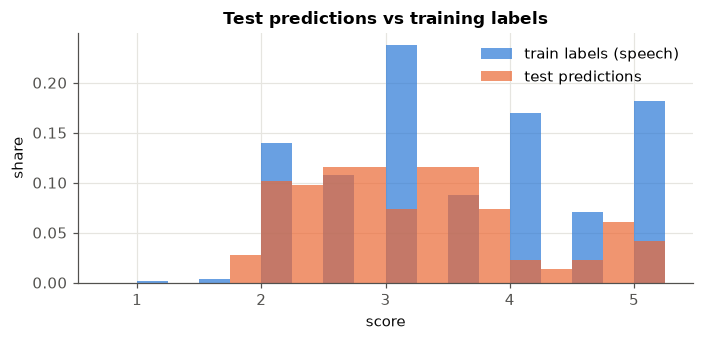

In [11]:
final = np.where(noise[tst], 0, np.clip(pred, 1, 5))
sub = pd.DataFrame({"filename": meta_b.filename[tst].values, "label": final})
sub.to_csv("submission.csv", index=False)
print(sub.shape, "written to submission.csv"); print(sub.head())

fig, ax = plt.subplots(figsize=(6.5, 3.2))
bins = np.arange(0.75, 5.5, 0.25)
ax.hist(y, bins=bins, color=BLUE, alpha=0.7, weights=np.ones(len(y)) / len(y), label="train labels (speech)")
ax.hist(final, bins=bins, color=ORANGE, alpha=0.7, weights=np.ones(len(final)) / len(final), label="test predictions")
ax.set(title="Test predictions vs training labels", xlabel="score", ylabel="share"); ax.legend()
plt.tight_layout(); plt.show()

## 8. Results and iteration history

| Version | Change | CV test-mix RMSE | Public LB RMSE |
|---|---|---|---|
| v1 | frozen WavLM-base + SVR, noise rule | 0.617 | 0.4705 |
| v3 | + fine-tuned DeBERTa-v3-base on transcripts | — | 0.3695 |
| v6 | + Whisper-encoder features, DeBERTa-v3-large | 0.504 | 0.3621 |
| v8 | length-aware stack with free intercept | 0.495 | 0.3546 |
| v10 | + end-to-end fine-tuned WavLM-base+ | 0.481 | 0.3401 |
| **v13** | **stack pruned to 4 inputs by repeated nested CV** | **0.477** | **0.3351** |

Ideas that were tested and **did not help**: hand-crafted prosody/transcript features and sentence embeddings once the transformers were in; Qwen2.5-1.5B hidden-state embeddings; a zero-shot LLM grammar judge (Qwen2.5-7B-Instruct, r = 0.56 with labels); mean+std pooling; truncating training clips to 45 s.

**Why the leaderboard is better than CV.** The public test split appears easier than the training folds (every version scored ~0.1 lower on the leaderboard); improvements in test-mix CV have tracked leaderboard improvements consistently, which is what matters for model selection.

## 9. Limitations and next steps

* Short clips remain the weak spot (CV RMSE ≈ 0.50 vs 0.43 on long clips) and are 69 % of the test set.
* Whisper occasionally hallucinates repeated words on silent stretches; cleaning repetitions or using word-level confidence could help the text models.
* Fine-tuned audio models were trained with one seed; seed-averaging (as done for DeBERTa) and a larger encoder (WavLM-large fine-tuning) are the most promising next steps.
* A joint audio–text model (e.g. word-aligned speech + text tokens) would replace the late fusion used here.